# Exploratory Data Analysis (EDA) — Airport Passenger Analysis

**Tools used:** Pandas, NumPy, Seaborn, Matplotlib  
**Dataset:** `airport_data.csv`

This notebook performs data understanding, cleaning, feature engineering, and visualization-driven EDA to uncover trends in air passenger traffic, seat capacity, flight activity, and route performance.

In [6]:
# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

import warnings
warnings.filterwarnings('ignore')

In [10]:
# Load dataset
df = pd.read_csv("airport_data.csv")

## 1) Basic Overview of Data

In [11]:
df.head()

,Origin_airport,Destination_airport,Origin_city,Destination_city,Passengers,Seats,Flights,Distance,Fly_date,Origin_population,Destination_population,Org_airport_lat,Org_airport_long,Dest_airport_lat,Dest_airport_long
0,MHK,AMW,"Manhattan, KS","Ames, IA",21,30,1,254,10/1/2008,122049,86219,39.140999,-96.670799,NaN,NaN
1,EUG,RDM,"Eugene, OR","Bend, OR",41,396,22,103,11/1/1990,284093,76034,44.124599,-123.211998,44.254101,-121.150002
2,EUG,RDM,"Eugene, OR","Bend, OR",88,342,19,103,12/1/1990,284093,76034,44.124599,-123.211998,44.254101,-121.150002
3,EUG,RDM,"Eugene, OR","Bend, OR",11,72,4,103,10/1/1990,284093,76034,44.124599,-123.211998,44.254101,-121.150002
4,MFR,RDM,"Medford, OR","Bend, OR",0,18,1,156,2/1/1990,147300,76034,42.374199,-122.873001,44.254101,-121.150002


In [16]:
# Shape and columns
print("Rows, Columns:", df.shape)
display(df.columns.to_frame(index=False).rename(columns={0:"Column"}))

# Data types
display(df.dtypes.to_frame("dtype"))

# Quick stats
display(df.describe(include="all").T)


Rows, Columns: (1048575, 15)


,Column
0,Origin_airport
1,Destination_airport
2,Origin_city
3,Destination_city
4,Passengers
5,Seats
6,Flights
7,Distance
8,Fly_date
9,Origin_population


,dtype
Origin_airport,object
Destination_airport,object
Origin_city,object
Destination_city,object
Passengers,int64
Seats,int64
Flights,int64
Distance,int64
Fly_date,object
Origin_population,int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Origin_airport,1048575,592,ORD,35928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination_airport,1048575,200,ORD,160054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Origin_city,1048575,476,"Chicago, IL",42689,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Destination_city,1048575,146,"Chicago, IL",187941,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Passengers,1048575.0,NaN,NaN,NaN,3007.274992,4712.801336,0.0,119.0,1306.0,3917.0,73505.0
Seats,1048575.0,NaN,NaN,NaN,4531.682225,6666.422366,0.0,182.0,2356.0,6041.0,99524.0
Flights,1048575.0,NaN,NaN,NaN,40.201157,51.263011,0.0,2.0,26.0,59.0,730.0
Distance,1048575.0,NaN,NaN,NaN,668.647372,544.197046,0.0,264.0,546.0,920.0,4962.0
Fly_date,1048575,240,12/1/2002,5812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Origin_population,1048575.0,NaN,NaN,NaN,5473725.333519,7768279.968964,13005.0,852019.0,2098618.0,8269386.0,38139592.0


## 2) Missing Values

In [17]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(3)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

display(missing_table)


,missing_count,missing_pct
Org_airport_lat,2066,0.197
Org_airport_long,2066,0.197
Dest_airport_lat,937,0.089
Dest_airport_long,937,0.089
Origin_airport,0,0.000
Destination_airport,0,0.000
Origin_city,0,0.000
Destination_city,0,0.000
Passengers,0,0.000
Seats,0,0.000


## 3) Date Parsing & Time Features

In [36]:
# Parse Fly_date

df["Fly_date"] = pd.to_datetime(df["Fly_date"], errors="coerce")

print("Date range:", df["Fly_date"].min(), "to", df["Fly_date"].max())
print("Invalid dates:", df["Fly_date"].isna().sum())

# Create time features

df["Year"] = df["Fly_date"].dt.year
df["Month"] = df["Fly_date"].dt.month

df[["Fly_date","Year","Month"]].head()

Date range: 1990-01-01 00:00:00 to 2009-12-01 00:00:00
Invalid dates: 0


,Fly_date,Year,Month
0,2008-10-01,2008,10
1,1990-11-01,1990,11
2,1990-12-01,1990,12
3,1990-10-01,1990,10
4,1990-02-01,1990,2


## 4) Data Quality Checks

In [37]:
# Check for impossible/edge values

checks = {
    "Passengers < 0": (df["Passengers"] < 0).sum(),
    "Seats < 0": (df["Seats"] < 0).sum(),
    "Flights < 0": (df["Flights"] < 0).sum(),
    "Distance <= 0": (df["Distance"] <= 0).sum()
}
display(pd.DataFrame(checks, index=["count"]).T)


# Outlier glance for core numeric columns

num_cols = ["Passengers", "Seats", "Flights", "Distance", "Origin_population", "Destination_population"]
display(df[num_cols].describe().T)


,count
Passengers < 0,0
Seats < 0,0
Flights < 0,0
Distance <= 0,1656


,count,mean,std,min,25%,50%,75%,max
Passengers,1048575.0,3.007275e+03,4.712801e+03,0.0,119.0,1306.0,3917.0,73505.0
Seats,1048575.0,4.531682e+03,6.666422e+03,0.0,182.0,2356.0,6041.0,99524.0
Flights,1048575.0,4.020116e+01,5.126301e+01,0.0,2.0,26.0,59.0,730.0
Distance,1048575.0,6.686474e+02,5.441970e+02,0.0,264.0,546.0,920.0,4962.0
Origin_population,1048575.0,5.473725e+06,7.768280e+06,13005.0,852019.0,2098618.0,8269386.0,38139592.0
Destination_population,1048575.0,8.542653e+06,6.576742e+06,12887.0,2154044.0,8761684.0,16395048.0,19161134.0


## 5) Feature Engineering

In [38]:
# Load factor & per-flight metrics

df["Load_factor"] = np.where(df["Seats"] > 0, df["Passengers"] / df["Seats"], np.nan)
df["Passengers_per_flight"] = np.where(df["Flights"] > 0, df["Passengers"] / df["Flights"], np.nan)
df["Seats_per_flight"] = np.where(df["Flights"] > 0, df["Seats"] / df["Flights"], np.nan)

display(df[["Load_factor","Passengers_per_flight","Seats_per_flight"]].describe().T)


,count,mean,std,min,25%,50%,75%,max
Load_factor,958932.0,0.634666,0.215577,0.0,0.506978,0.660761,0.795762,1.536111
Passengers_per_flight,1045376.0,71.087106,49.381122,0.0,34.333333,68.441018,101.023141,553.000000
Seats_per_flight,1045376.0,111.507936,67.989982,0.0,63.000000,122.000000,144.000000,15514.000000


## 6) Univariate Analysis

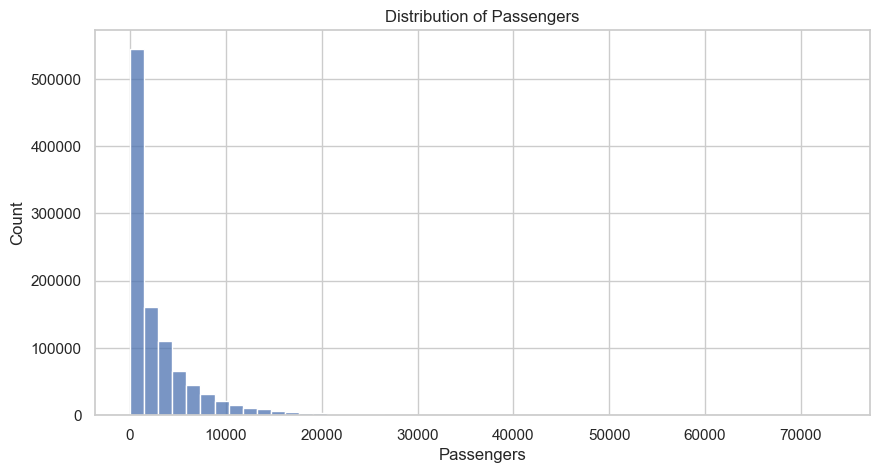

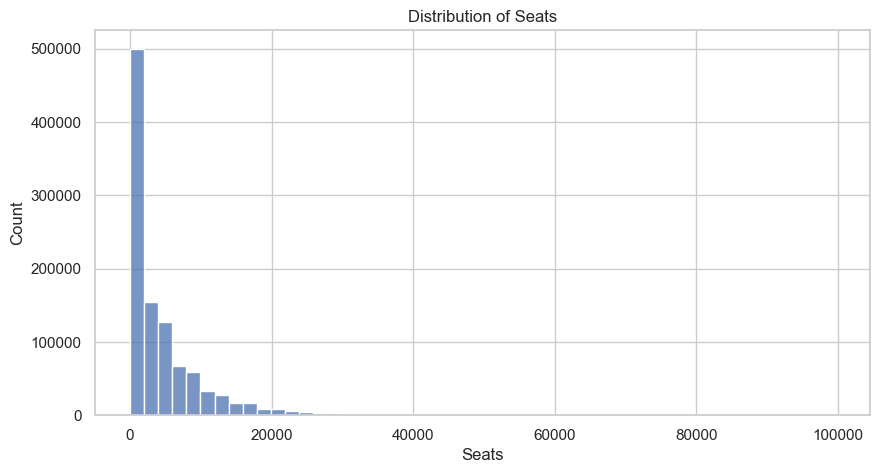

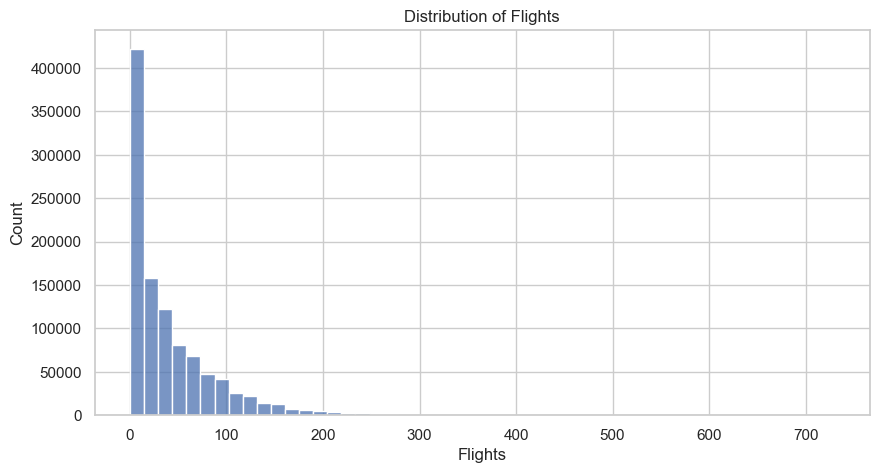

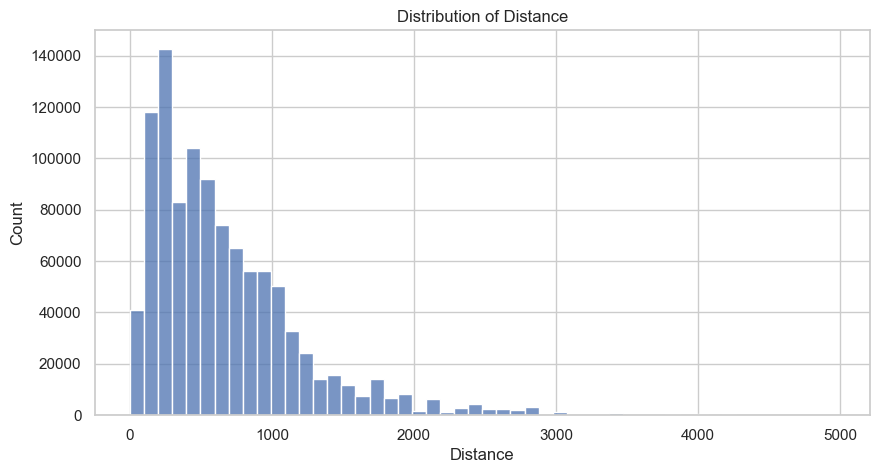

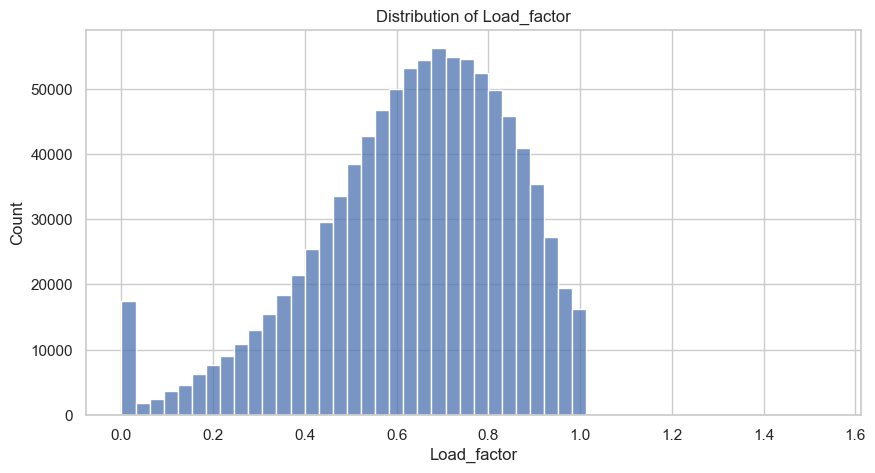

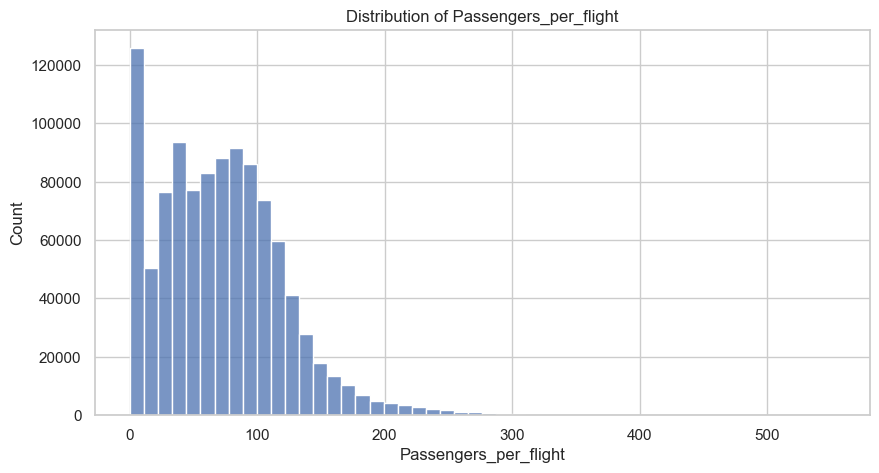

In [39]:
# Histograms for main numeric columns

num_cols = ["Passengers", "Seats", "Flights", "Distance", "Load_factor", "Passengers_per_flight"]


for col in num_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), bins=50, kde=False)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


## 7) Correlation Analysis

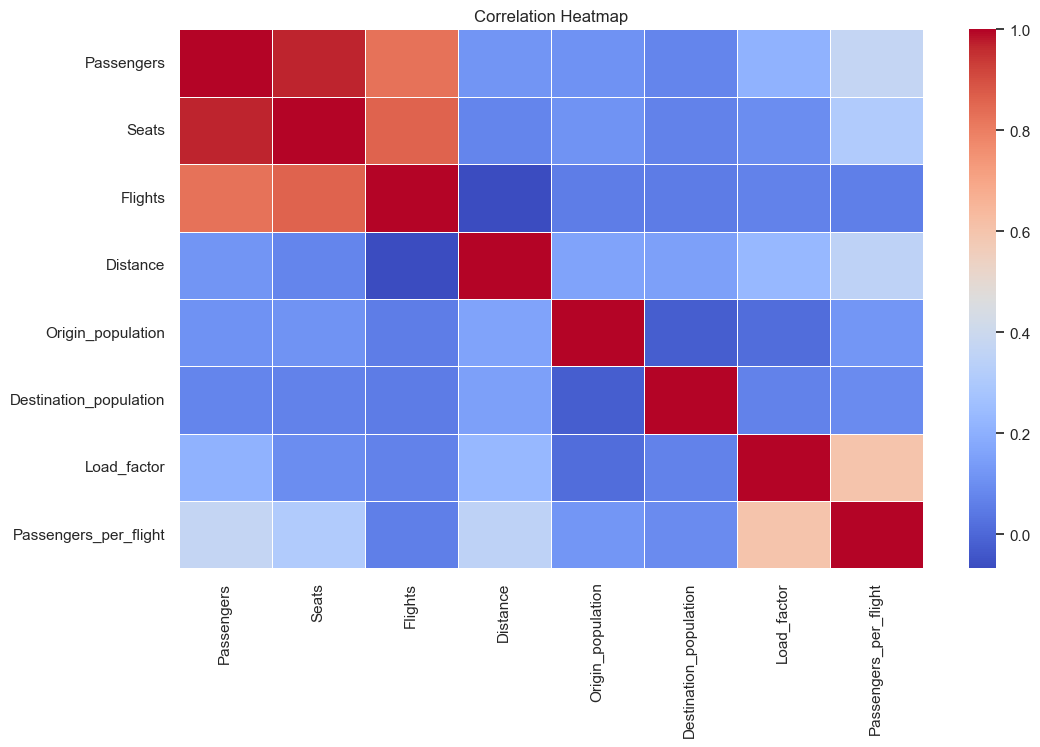

In [44]:
# Correlation heatmap

corr_cols = ["Passengers", "Seats", "Flights", "Distance", "Origin_population", "Destination_population", "Load_factor", "Passengers_per_flight"]
corr = df[corr_cols].corr()

plt.figure(figsize=(12, 7))
sns.heatmap(corr, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


## 8) Route-Level Insights

,Origin_airport,Destination_airport,Passengers
5280,LAX,ORD,22936415
5966,MCO,ATL,22754168
515,ATL,DFW,21626001
2594,DFW,ATL,21315212
5514,LGA,ORD,20147022
8732,SFO,ORD,18311167
4354,HOU,DAL,17717480
9511,TPA,ATL,17462127
556,ATL,TPA,17409235
5484,LGA,ATL,17173288


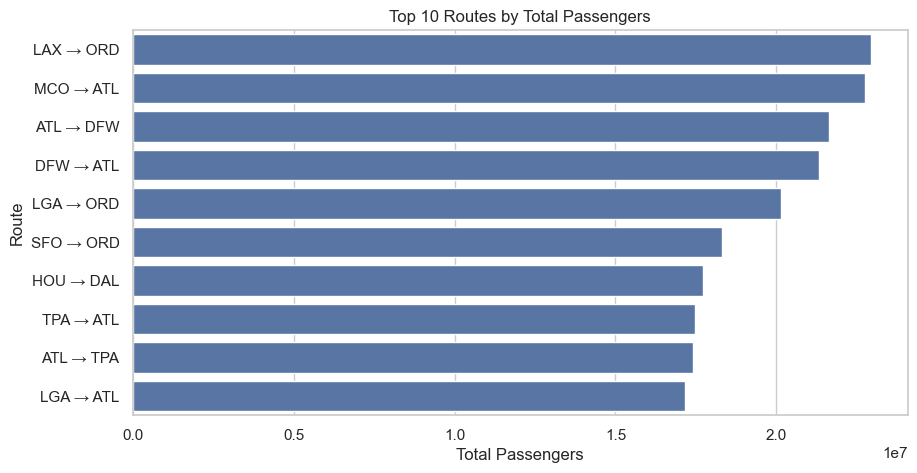

In [41]:
# Create a route field

df["Route"] = df["Origin_airport"] + " → " + df["Destination_airport"]

# Top 10 routes by passengers

top_routes = (df.groupby(["Origin_airport","Destination_airport"], as_index=False)["Passengers"]
                .sum()
                .sort_values("Passengers", ascending=False)
                .head(10))

display(top_routes)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_routes, x="Passengers", y=top_routes["Origin_airport"] + " → " + top_routes["Destination_airport"])
plt.title("Top 10 Routes by Total Passengers")
plt.xlabel("Total Passengers")
plt.ylabel("Route")
plt.show()

## 9) Airport-Level Insights

,Origin_airport,Passengers
35,ATL,149839190
420,ORD,128781763
142,DFW,125037714
308,LAX,106448229
317,LGA,92984012
343,MCO,90602268
440,PHX,81961961
382,MSP,80180208
306,LAS,77884842
181,EWR,74643114


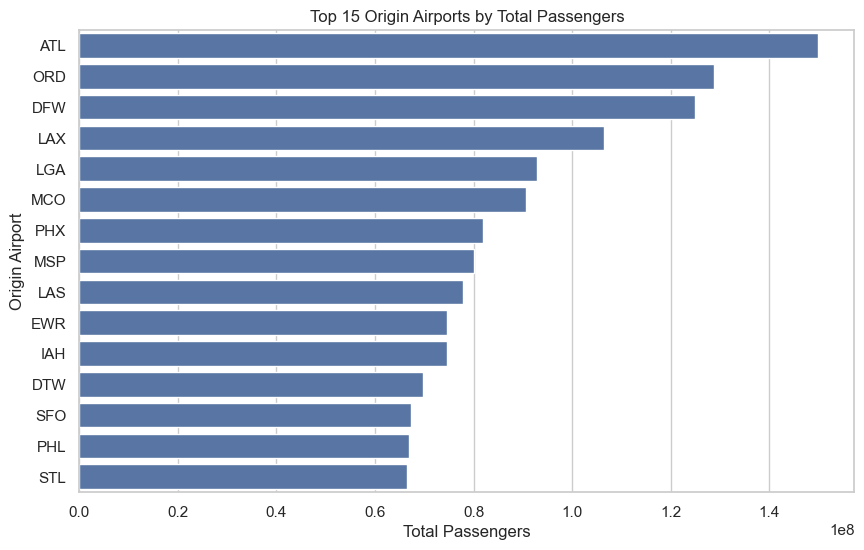

,Destination_airport,Passengers
20,ATL,577954147
150,ORD,528648148
56,DFW,458322527
67,DTW,251467874
79,EWR,209083721
33,BOS,190600918
128,MIA,143429156
180,TPA,134023409
125,MDW,118459314
50,DAL,73576938


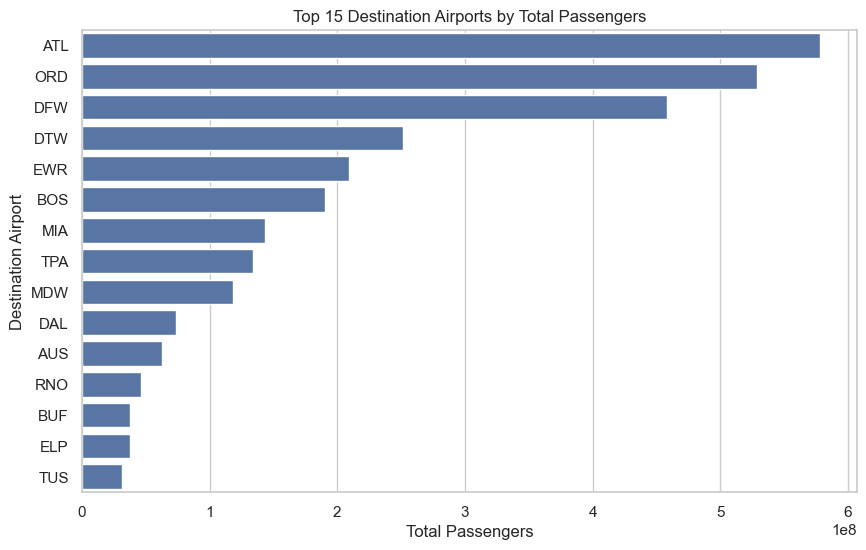

In [42]:
# Top origin airports by passengers

top_origin = (df.groupby("Origin_airport", as_index=False)["Passengers"].sum().sort_values("Passengers", ascending=False).head(15))

display(top_origin)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_origin, x="Passengers", y="Origin_airport")
plt.title("Top 15 Origin Airports by Total Passengers")
plt.xlabel("Total Passengers")
plt.ylabel("Origin Airport")
plt.show()

# Top destination airports by passengers

top_dest = (df.groupby("Destination_airport", as_index=False)["Passengers"].sum().sort_values("Passengers", ascending=False).head(15))

display(top_dest)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_dest, x="Passengers", y="Destination_airport")
plt.title("Top 15 Destination Airports by Total Passengers")
plt.xlabel("Total Passengers")
plt.ylabel("Destination Airport")
plt.show()

## 10) Time Series Trends

,Fly_date,Passengers
0,1990-01-31,10314335
1,1990-02-28,10151588
2,1990-03-31,12459144
3,1990-04-30,11779209
4,1990-05-31,11685614


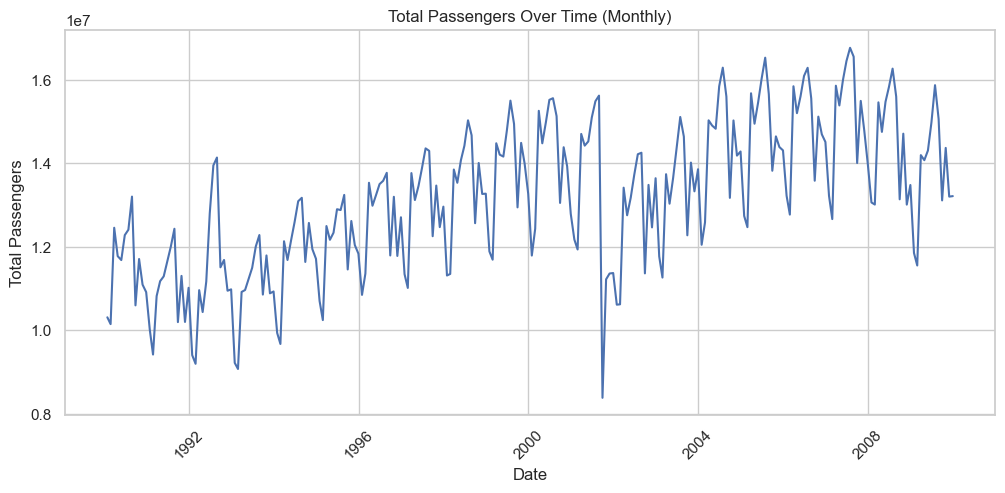

In [35]:
# Monthly time series of passengers

monthly = (
    df.groupby(pd.Grouper(key="Fly_date", freq="ME"))["Passengers"].sum().reset_index())

display(monthly.head())

plt.figure(figsize=(12, 5))
plt.plot(monthly["Fly_date"], monthly["Passengers"])
plt.title("Total Passengers Over Time (Monthly)")
plt.xlabel("Date")
plt.ylabel("Total Passengers")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## 11) Distance Buckets Analysis

,Distance_bucket,Passengers,Seats,Flights,Avg_Load_Factor,Avg_Passengers_per_flight
0,0-200,307129684,542141700,7236344,0.541603,45.768079
1,200-500,895770498,1418830311,14163461,0.607287,60.463038
2,500-1000,1142639978,1678992996,13535223,0.660699,75.024221
3,1000-2000,696995386,963419932,6348472,0.705695,99.852272
4,2000-5000,110817829,148423750,870428,0.726593,107.294049


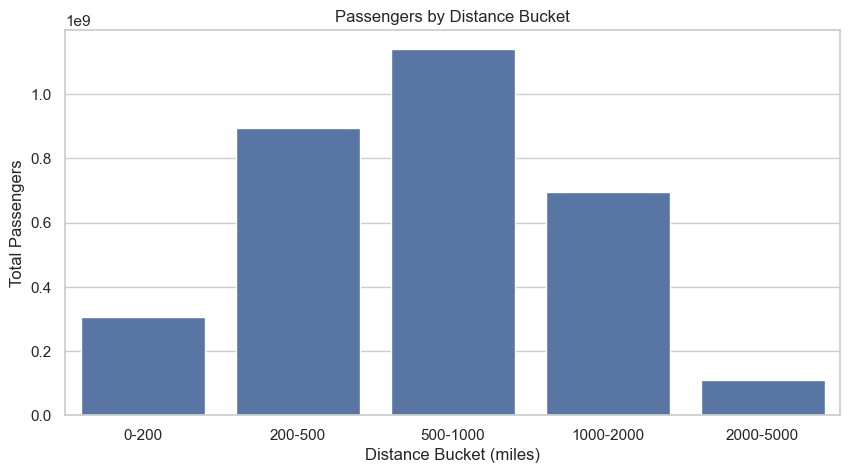

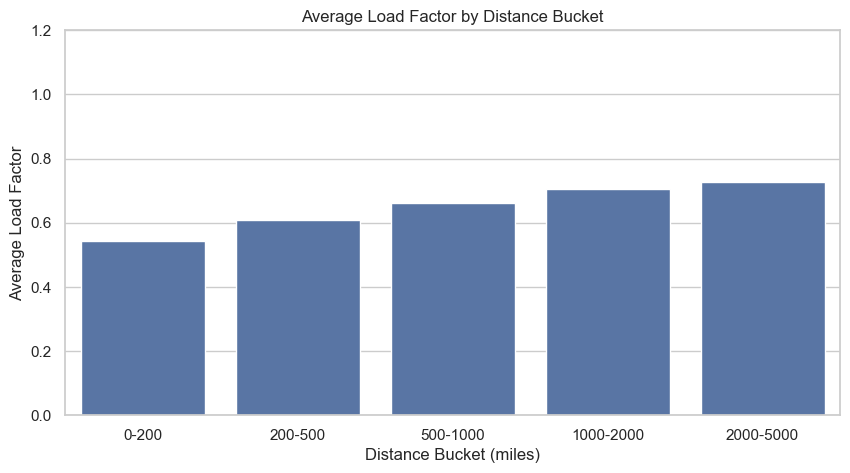

In [43]:
# Distance bins

bins = [0, 200, 500, 1000, 2000, 5000]
labels = ["0-200", "200-500", "500-1000", "1000-2000", "2000-5000"]
df["Distance_bucket"] = pd.cut(df["Distance"], bins=bins, labels=labels, include_lowest=True)

dist_summary = (df.groupby("Distance_bucket", as_index=False)
                  .agg(Passengers=("Passengers","sum"),
                       Seats=("Seats","sum"),
                       Flights=("Flights","sum"),
                       Avg_Load_Factor=("Load_factor","mean"),
                       Avg_Passengers_per_flight=("Passengers_per_flight","mean")))

display(dist_summary)

plt.figure(figsize=(10,5))
sns.barplot(data=dist_summary, x="Distance_bucket", y="Passengers")
plt.title("Passengers by Distance Bucket")
plt.xlabel("Distance Bucket (miles)")
plt.ylabel("Total Passengers")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=dist_summary, x="Distance_bucket", y="Avg_Load_Factor")
plt.title("Average Load Factor by Distance Bucket")
plt.xlabel("Distance Bucket (miles)")
plt.ylabel("Average Load Factor")
plt.ylim(0, 1.2)
plt.show()


## 12) Geo Features (Lat/Long sanity check)

,missing_count
Org_airport_lat,2066
Org_airport_long,2066
Dest_airport_lat,937
Dest_airport_long,937


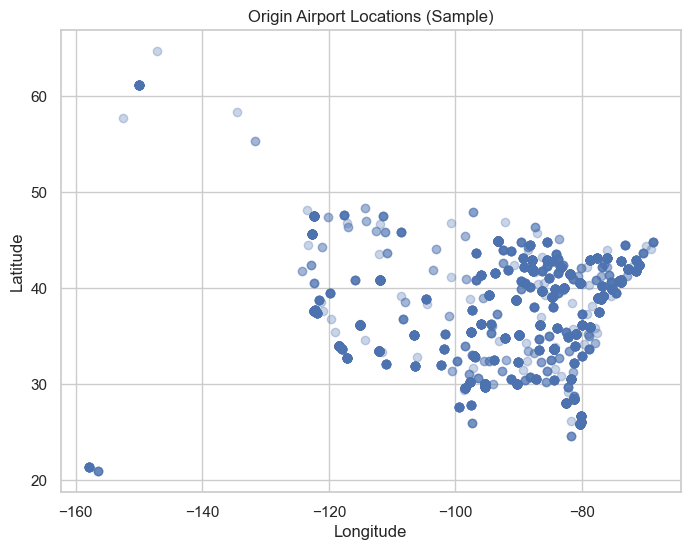

In [34]:
# Check missing geo

geo_cols = ["Org_airport_lat","Org_airport_long","Dest_airport_lat","Dest_airport_long"]
display(df[geo_cols].isna().sum().to_frame("missing_count"))

# Scatter plot: origin airports locations (sample for speed)

sample_geo = df.dropna(subset=["Org_airport_lat","Org_airport_long"]).sample(5000, random_state=42)

plt.figure(figsize=(8,6))
plt.scatter(sample_geo["Org_airport_long"], sample_geo["Org_airport_lat"], alpha=0.3)
plt.title("Origin Airport Locations (Sample)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()